In [5]:
%load_ext autoreload
%autoreload 2
%aimport
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Modules to reload:
all-except-skipped

Modules to skip:



In [40]:
from hydra import initialize, compose
from hydra.utils import instantiate

with initialize(config_path="../config"):
    cfg = compose("config", overrides=['datasets.galsim_blends_coadds.prior.n_dithers=10'])

In [41]:
coadd_ds = instantiate(cfg.datasets.galsim_blends_coadds)
coadd_ds.prior.n_dithers

10

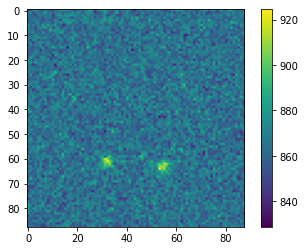

In [42]:
import matplotlib.pyplot as plt
b = coadd_ds[0]
plt.imshow(b['images'][0].numpy())
plt.colorbar()

In [193]:
b['images'][0].shape

torch.Size([88, 88])

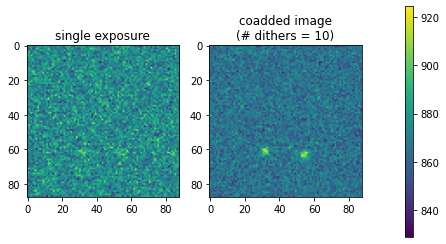

In [44]:
y11 = b['noisy'][0].numpy()
y22 = b['images'][0].numpy()
plt.subplot(1, 2, 1)
plt.imshow(y11)
plt.title("single exposure")
plt.subplot(1, 2, 2)
plt.imshow(y22)
plt.title("coadded image\n(# dithers = 10)")

cax = plt.axes([1, 0.1, 0.02, 0.8])
plt.colorbar(cax=cax)

plt.show()


In [36]:
from hydra import initialize, compose
from hydra.utils import instantiate

with initialize(config_path="../config"):
    cfg = compose("config", overrides=['datasets.galsim_blends_coadds.prior.n_dithers=25'])

In [37]:
coadd_ds = instantiate(cfg.datasets.galsim_blends_coadds)
coadd_ds.prior.n_dithers

25

In [38]:
import matplotlib.pyplot as plt
b = coadd_ds[0]

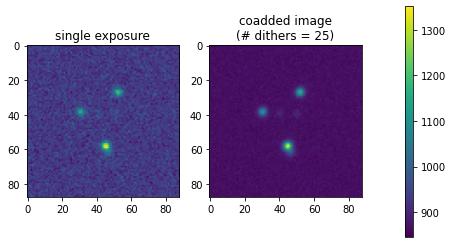

In [39]:
y1 = b['noisy'][0].numpy()
y2 = b['images'][0].numpy()
plt.subplot(1, 2, 1)
plt.imshow(y1)
plt.title("single exposure")
plt.subplot(1, 2, 2)
plt.imshow(y2)
plt.title("coadded image\n(# dithers = 25)")

cax = plt.axes([1, 0.1, 0.02, 0.8])
plt.colorbar(cax=cax)

plt.show()

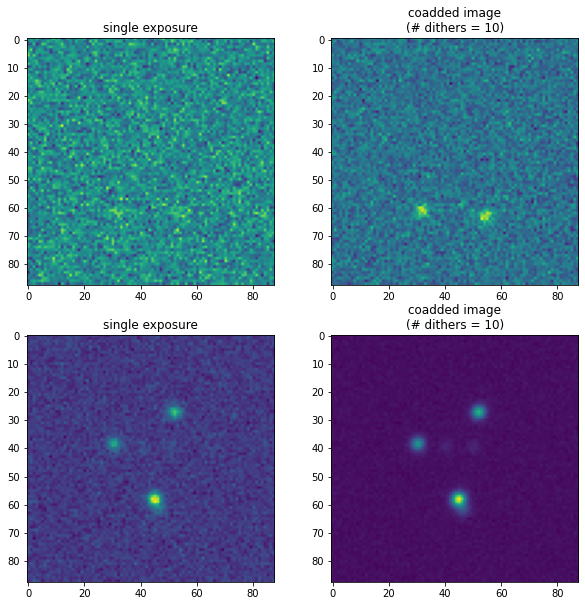

In [62]:
fig, axs = plt.subplots(2, 2, figsize=(10,10))
axs[0,0].imshow(y11)
axs[0,0].set_title("single exposure")
axs[0,1].imshow(y22)
axs[0,1].set_title("coadded image\n(# dithers = 10)")
axs[1,0].imshow(y1)
axs[1,0].set_title("single exposure")
axs[1,1].imshow(y2)
axs[1,1].set_title("coadded image\n(# dithers = 10)")

plt.show()


# Test conversion to tile_params

In [260]:
full_cat, dithers = coadd_ds._sample_full_catalog()
coadd_ds._get_tile_params(full_cat)
# full_cat.to_tile_params(4, 1, ignore_extra_sources=True)

{'n_sources': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 1, 0, 0, 1, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]]),
 'locs': tensor([[[[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 0.0000]],
 
          [[0.0000, 

{'galaxy_bools': tensor([[[[[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[1.]],

          [[0.]],

          [[0.]],

          [[1.]],

          [[0.]]],


         [[[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]]],


         [[[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]]],


         [[[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]]],


         [[[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]],

          [[0.]]],


         [[[0.]],

    